In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --------------------------
# Dataset personalizzato .npy
# --------------------------
class NPYSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path  = os.path.join(self.mask_dir, self.masks[idx])
    
        # Carica i file .npy
        image = np.load(image_path).astype(np.float32) / 255.0  # (H, W, C)
        mask  = np.load(mask_path).astype(np.int64)             # (H, W)
    
        # Applica le trasformazioni Albumentations (richiede np.ndarray)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        else:
            # Se non c'è transform, converti manualmente in tensor
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask).long()

        return image, mask

# --------------------------
# Trasformazioni (resize, optional)
# --------------------------
transform = transforms.Compose([
    A.Resize(128, 256),
    #A.HorizontalFlip(p=0.5),
    #A.Rotate(limit=15, p=0.5),
    # Per evitare problemi con la maschera, solo trasformazioni geometriche

    ToTensorV2()  # converte immagine e maschera in torch.Tensor
])

val_transform=transform=A.Compose([  # no augmentation per val, solo resize + ToTensor
        A.Resize(128, 256),
        ToTensorV2(),
    ])
# --------------------------
# Dati e DataLoader
# --------------------------
train_dataset = NPYSegmentationDataset("./cityscapes/train/image", "./cityscapes/train/label", transform=transform)
val_dataset   = NPYSegmentationDataset("./cityscapes/val/image", "./cityscapes/val/label", transform=val_transform)
test_dataset   = NPYSegmentationDataset("./cityscapes/test/image", "./cityscapes/test/label", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Itera su un batch e stampa le shape
#for images, labels in train_loader:
#    print("Image batch shape:", images.shape)   # (B, 3, H, W)
#    print("Label batch shape:", labels.shape)   # (B, H, W)
#    break  # solo il primo batch

/home/user/computer-vision/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from torch.utils.tensorboard import SummaryWriter
# --------------------------
# DeepLabV3
# --------------------------
num_classes = 19

model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# --------------------------
# Loss e ottimizzatore
# --------------------------
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ---------------------
# Metrics
# ---------------------
def compute_pixel_accuracy(preds, targets):
    correct = (preds == targets).sum().item()
    total = (targets != -1).sum().item()  # Esclude i pixel con label -1
    return correct / total if total > 0 else 0.0

def compute_mean_iou(preds, targets, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (targets == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(1.0)
        else:
            ious.append(intersection / union)
    return np.mean(ious)

# --------------------------
# Validazione
# --------------------------
def validate(model, dataloader, criterion):
    model.eval()
    val_loss = 0.0
    total_iou = 0.0
    total_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            iou = compute_mean_iou(preds, masks, num_classes)
            acc = compute_pixel_accuracy(preds, masks)

            total_iou += iou
            total_acc += acc
            num_batches += 1

    return val_loss / num_batches, total_iou / num_batches, total_acc / num_batches

# --------------------------
# Training
# --------------------------
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, log_dir="runs/DeepLabV3-50-19classes"):
    writer = SummaryWriter(log_dir)  # Inizializza TensorBoard writer
    best_miou=0
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        val_loss, val_iou, val_acc = validate(model, val_loader, criterion)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val mIoU: {val_iou:.4f} | "
              f"Val PixelAcc: {val_acc:.4f}")


        # Scrivi le metriche su TensorBoard
        writer.add_scalar("Loss/train", avg_train_loss, epoch + 1)
        writer.add_scalar("Loss/val", val_loss, epoch + 1)
        writer.add_scalar("mIoU/val", val_iou, epoch + 1)
        writer.add_scalar("PixelAccuracy/val", val_acc, epoch + 1)

         # Salva il modello se migliora il mIoU
        if val_iou > best_miou:
            best_miou = val_iou
            torch.save(model.state_dict(), f"{log_dir}/best_model.pth")
            print(f"Modello salvato all'epoca {epoch+1} con mIoU {val_iou:.4f}")

# --------------------------
# Avvio
# --------------------------
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=50)

/home/user/computer-vision/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/computer-vision/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50] Train Loss: 0.8662 | Val Loss: 0.5584 | Val mIoU: 0.3404 | Val PixelAcc: 0.8574
Modello salvato all'epoca 1 con mIoU 0.3404
Epoch [2/50] Train Loss: 0.4729 | Val Loss: 0.4529 | Val mIoU: 0.3438 | Val PixelAcc: 0.8685
Modello salvato all'epoca 2 con mIoU 0.3438
Epoch [3/50] Train Loss: 0.3811 | Val Loss: 0.4219 | Val mIoU: 0.3618 | Val PixelAcc: 0.8728
Modello salvato all'epoca 3 con mIoU 0.3618
Epoch [4/50] Train Loss: 0.3283 | Val Loss: 0.3797 | Val mIoU: 0.3811 | Val PixelAcc: 0.8837
Modello salvato all'epoca 4 con mIoU 0.3811
Epoch [5/50] Train Loss: 0.2912 | Val Loss: 0.3798 | Val mIoU: 0.3739 | Val PixelAcc: 0.8833
Epoch [6/50] Train Loss: 0.2699 | Val Loss: 0.3681 | Val mIoU: 0.3823 | Val PixelAcc: 0.8874
Modello salvato all'epoca 6 con mIoU 0.3823
Epoch [7/50] Train Loss: 0.2428 | Val Loss: 0.3854 | Val mIoU: 0.3943 | Val PixelAcc: 0.8823
Modello salvato all'epoca 7 con mIoU 0.3943
Epoch [8/50] Train Loss: 0.2297 | Val Loss: 0.3833 | Val mIoU: 0.3843 | Val PixelAcc:

In [3]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_metrics(preds, labels, num_classes):
    cm = confusion_matrix(
        labels.flatten(),
        preds.flatten(),
        labels=list(range(num_classes))
    )
    intersection = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - intersection
    iou = intersection / np.maximum(union, 1)
    miou = np.mean(iou)
    pixel_acc = np.sum(intersection) / np.sum(cm)
    return pixel_acc, miou, iou

def show_rescaled_image(img_tensor):
    """
    Visualizza un'immagine torch.Tensor [3, H, W] anche se ha valori molto piccoli
    """
    img = img_tensor.detach().cpu()
    if img.dtype != torch.float32:
        img = img.float()

    # Riscalamento automatico al range [0, 1]
    min_val = img.min()
    max_val = img.max()
    img = (img - min_val) / (max_val - min_val + 1e-8)

    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.axis('off')
    plt.title("Rescaled RGB Image")
    plt.show()

def visualize_prediction(image, label, prediction, class_colors=None):
    print(image.shape)
    print(image.min().item())
    print(image.max().item())
    #image_np = image.permute(1, 2, 0).cpu().numpy()
    label_np = label.cpu().numpy()
    pred_np = prediction.cpu().numpy()

    if class_colors is not None:
        label_np = np.stack([class_colors[c] for c in label_np.flatten()]).reshape(label_np.shape + (3,))
        pred_np = np.stack([class_colors[c] for c in pred_np.flatten()]).reshape(pred_np.shape + (3,))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    show_rescaled_image(image)
    #plt.imshow(image_np)
    #plt.title("Input Image")

    plt.subplot(1, 3, 2)
    plt.imshow(label_np)
    plt.title("Ground Truth")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np)
    plt.title("Prediction")

    plt.tight_layout()
    plt.show()



def test_model(model, test_loader, num_classes=8, show_example=True, class_colors=None):
    model.eval()
    all_preds = []
    all_labels = []
    example_shown = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']

            if outputs.shape[-2:] != masks.shape[-2:]:
                outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False)

            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(masks.cpu())

            # Mostra solo un tot esempi
            if show_example and example_shown<3:
                visualize_prediction(images[example_shown], masks[example_shown], preds[example_shown], class_colors)
                example_shown = example_shown+1

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pixel_acc, miou, iou_per_class = compute_metrics(all_preds, all_labels, num_classes)

    print(f"\nTest Results:")
    print(f"Pixel Accuracy: {pixel_acc:.4f}")
    print(f"Mean IoU: {miou:.4f}")
    print("IoU per class:")
    for i, iou in enumerate(iou_per_class):
        print(f"  Class {i}: {iou:.4f}")

    return pixel_acc, miou, iou_per_class

torch.Size([3, 128, 256])
0.0
0.003921568859368563


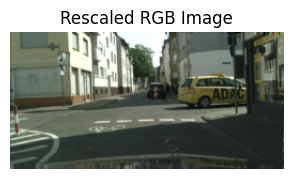

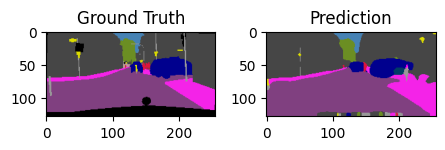

torch.Size([3, 128, 256])
0.0
0.003921568859368563


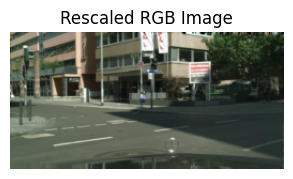

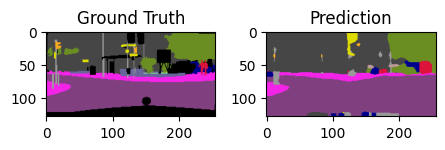

torch.Size([3, 128, 256])
4.613610144588165e-05
0.003921568859368563


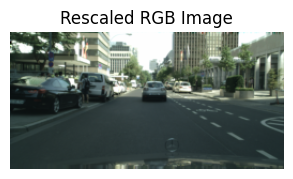

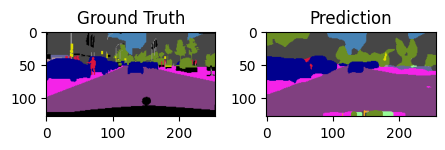


Test Results:
Pixel Accuracy: 0.8922
Mean IoU: 0.4538
IoU per class:
  Class 0: 0.9549
  Class 1: 0.6603
  Class 2: 0.8051
  Class 3: 0.2635
  Class 4: 0.2072
  Class 5: 0.1620
  Class 6: 0.1595
  Class 7: 0.3033
  Class 8: 0.8068
  Class 9: 0.4718
  Class 10: 0.8628
  Class 11: 0.4255
  Class 12: 0.2088
  Class 13: 0.8026
  Class 14: 0.2751
  Class 15: 0.4364
  Class 16: 0.2790
  Class 17: 0.1385
  Class 18: 0.3990


(np.float64(0.8921646058044803),
 np.float64(0.45379075993872126),
 array([0.95487644, 0.66031258, 0.80511247, 0.26354702, 0.20718563,
        0.16197627, 0.15948911, 0.30326999, 0.80679614, 0.4718487 ,
        0.86275455, 0.42545589, 0.20875998, 0.80258823, 0.27505568,
        0.43641862, 0.27902113, 0.13852983, 0.3990262 ]))

In [ ]:
class_colors = [
    (128, 64,128),   # 0: road fucsia scuro
    (244, 35,232),   # 1: sidewalk fucsia
    ( 70, 70, 70),   # 2: building grigio scuro
    (102,102,156),   # 3: wall azzurrino scuro
    (190,153,153),   # 4: fence rosa chiarissimo
    (153,153,153),   # 5: pole  grigio
    (250,170, 30),   # 6: traffic light arancione
    (220,220,  0),   # 7: traffic sign giallo
    (107,142, 35),   # 8: vegetation verde scuretto
    (152,251,152),   # 9: terrain verde chiarissimo
    ( 70,130,180),   #10: sky azzurro 
    (220, 20, 60),   #11: person rosa-rosso fluo
    (255,  0,  0),   #12: rider rosso
    (  0,  0,142),   #13: car bllu scuro
    (  0,  0, 70),   #14: truck blu molto piu scuro
    (  0, 60,100),   #15: bus azzurro scuro
    (  0, 80,100),   #16: train verde acqua scuro
    (  0,  0,230),   #17: motorcycle blu
    (250,0,250),     #18: bycycle
    (0, 0, 0),   #-1: unlabeled nero
]

test_model(model, test_loader, num_classes=19, class_colors=class_colors)